Salary Prediction System


In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import  PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
df = pd.read_csv("Salary Data.csv")
print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [43]:
df.shape

(375, 6)

In [44]:
null_values = df.isnull().sum()
print(null_values)

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [32]:
df.dropna(inplace=True)

In [45]:
total_null_values = df.isnull().sum().sum()
print(total_null_values)

12


0


In [48]:
df.shape

(375, 6)

In [49]:
df.head(5)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [53]:
df['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD', nan], dtype=object)

In [55]:
df['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [56]:



df['Job Title'].fillna('Unknown', inplace=True)



/tmp/ipython-input-1928927825.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Job Title'].fillna('Unknown', inplace=True)


In [57]:

def extract_level(title):
    title = title.lower()
    if 'junior' in title:
        return 'Junior'
    elif 'senior' in title:
        return 'Senior'
    elif 'director' in title or 'chief' in title or 'head' in title:
        return 'Director'
    elif 'manager' in title:
        return 'Manager'
    elif 'principal' in title or 'lead' in title:
        return 'Lead'
    else:
        return 'Other'

df['Job_Level'] = df['Job Title'].apply(extract_level)



In [58]:

df.drop(columns=['Job Title'], inplace=True)



In [59]:

df = pd.get_dummies(
    df,
    columns=['Gender', 'Education Level', 'Job_Level'],
    drop_first=True,
    dtype=int
)

print(df.shape)


(375, 11)


In [61]:
df.head(5)

,Age,Years of Experience,Salary,Gender_Male,Education Level_Master's,Education Level_PhD,Job_Level_Junior,Job_Level_Lead,Job_Level_Manager,Job_Level_Other,Job_Level_Senior
0,32.0,5.0,90000.0,1,0,0,0,0,0,1,0
1,28.0,3.0,65000.0,0,1,0,0,0,0,1,0
2,45.0,15.0,150000.0,1,0,1,0,0,0,0,1
3,36.0,7.0,60000.0,0,0,0,0,0,0,1,0
4,52.0,20.0,200000.0,1,1,0,0,0,0,0,0


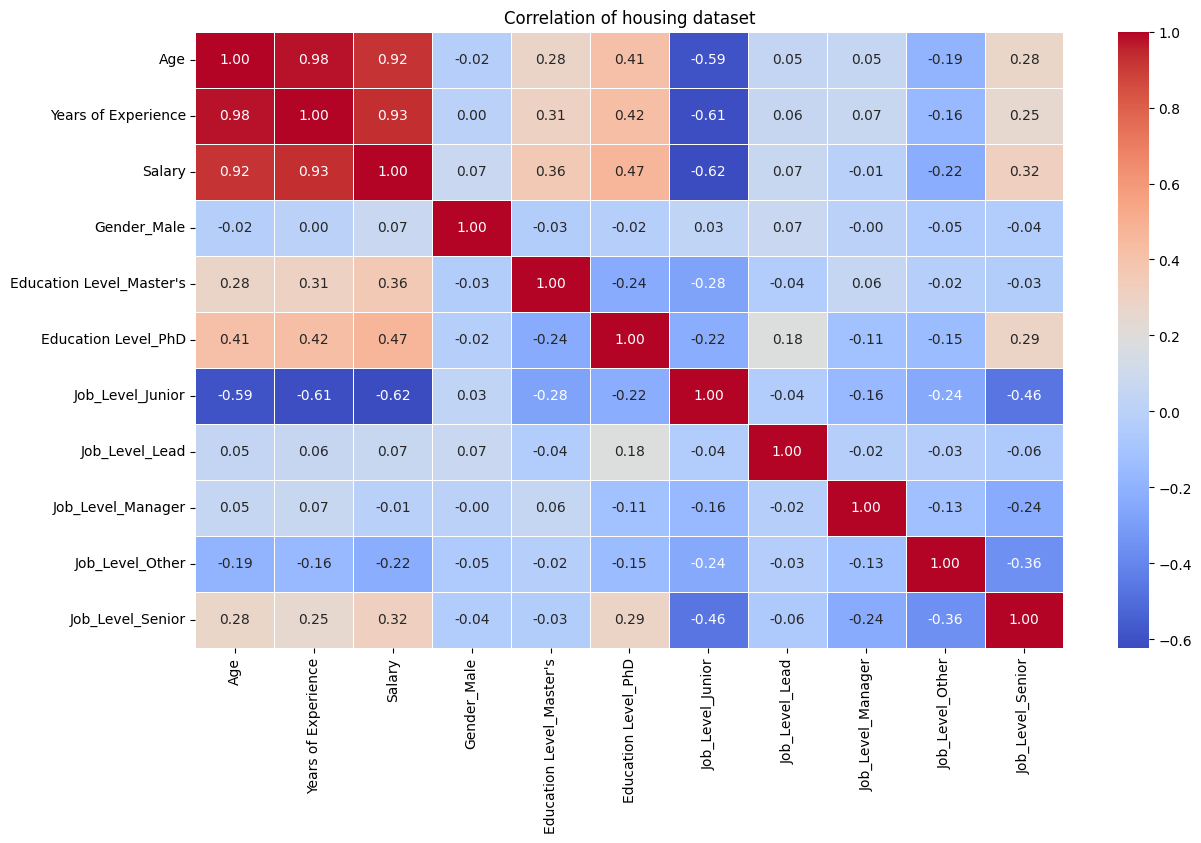

In [63]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of housing dataset')
plt.show()

In [71]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)


In [72]:
X = df.drop("Salary", axis=1)
y = df["Salary"]


In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [74]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
from sklearn.pipeline import Pipeline
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ]),

    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("linear", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}


results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append([name, r2, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score (Higher better)", "RMSE (Lower better)"]
).sort_values(by="R2 Score (Higher better)", ascending=False)

print("\nModel Comparison:\n")
print(results_df)


best_model = results_df.iloc[0]["Model"]
print(f"\nBest model based on R2 Score: {best_model}")



Model Comparison:

                   Model  R2 Score (Higher better)  RMSE (Lower better)
3          Random Forest                  0.910759         14704.923029
1       Ridge Regression                  0.875164         17392.004451
0      Linear Regression                  0.872494         17577.054673
2  Polynomial Regression                  0.856991         18614.936682

Best model based on R2 Score: Random Forest


In [76]:
print("\nEnter employee details:")

age = int(input("Age: "))
experience = float(input("Years of Experience: "))
gender = input("Gender (Male/Female): ").strip()
education = input("Education (Bachelor's/Master's/PhD): ").strip()
job_level = input("Job Level (Junior/Senior/Manager/Director/Lead/Other): ").strip()


input_data = pd.DataFrame(columns=X.columns)
input_data.loc[0] = 0

input_data["Age"] = age
input_data["Years of Experience"] = experience


if f"Gender_{gender}" in input_data.columns:
    input_data[f"Gender_{gender}"] = 1


edu_col = f"Education Level_{education}"
if edu_col in input_data.columns:
    input_data[edu_col] = 1


job_col = f"Job_Level_{job_level}"
if job_col in input_data.columns:
    input_data[job_col] = 1


Enter employee details:
Age: 32
Years of Experience: 5
Gender (Male/Female): Male
Education (Bachelor's/Master's/PhD): Bachelor's
Job Level (Junior/Senior/Manager/Director/Lead/Other): Other


In [77]:
prediction = model.predict(input_data)[0]

print(f"\nEstimated Salary: {prediction:,.2f}")


Estimated Salary: 55,837.86
